## Try overfitting

In [1]:
import numpy as np
import torch
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from jetnet.datasets import JetNet
MASK = True
NUM_PARTICLES = 30
TRAIN_SPLIT = 0.7
feature_maxes = JetNet.fpnd_norm.feature_maxes
if MASK:
    feature_maxes = feature_maxes + [1]

data_args = {
    "jet_type": ["g"],
    "data_dir": "datasets/jetnet",
    "num_particles": NUM_PARTICLES,
    "particle_features": (
        JetNet.ALL_PARTICLE_FEATURES if MASK else JetNet.ALL_PARTICLE_FEATURES[:-1]
    ),
    # The order of the list is preserved in the retrieved data
    "jet_features": ["eta", "pt", "mass", "num_particles", "type"],
    # "particle_normalisation": particle_normalizer,
    "split_fraction": [TRAIN_SPLIT, 1 - TRAIN_SPLIT, 0],
    "download": True
}
X_train = JetNet(**data_args, split="train")
X_test = JetNet(**data_args, split="valid")

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [3]:
from util.coordinates import transform_rel_particle_coordinates_to_cartesian


In [4]:
from scipy.stats import anderson

X_train_particle_transformed = transform_rel_particle_coordinates_to_cartesian(X_train)

e_c = np.array(X_train_particle_transformed[:, :, 0].flatten())
e_c_mirrored = np.concatenate([e_c, -e_c])
p_x = np.array(X_train_particle_transformed[:, :, 1].flatten())
p_y = np.array(X_train_particle_transformed[:, :, 2].flatten())
p_z = np.array(X_train_particle_transformed[:, :, 3].flatten())
final_scale = min([anderson(data).fit_result.params.scale for data in [e_c_mirrored, p_x, p_y, p_z]])

In [27]:
n_samples = 1000
train_cloud_transformed = X_train_particle_transformed[:n_samples]
train_cloud_transformed.shape

torch.Size([1000, 30, 4])

In [6]:
final_scale

42.238216

In [7]:
train_cloud_transformed = (1/final_scale) * train_cloud_transformed
train_cloud_transformed

tensor([[[ 7.6094e+00, -5.7159e-01,  4.0906e+00, -6.3909e+00],
         [ 7.0355e+00, -5.4894e-01,  3.7734e+00, -5.9126e+00],
         [ 5.1934e+00, -3.8855e-01,  2.7898e+00, -4.3632e+00],
         ...,
         [ 2.2362e-01,  1.9840e-02,  1.2721e-01, -1.8284e-01],
         [ 2.1080e-01, -2.6593e-02,  1.1701e-01, -1.7331e-01],
         [ 2.1384e-01, -1.8133e-02,  1.1645e-01, -1.7843e-01]],

        [[ 6.9738e+00, -4.5749e+00, -1.8063e+00, -4.9438e+00],
         [ 2.0380e+00, -1.3553e+00, -4.6479e-01, -1.4493e+00],
         [ 1.9154e+00, -1.2604e+00, -4.7951e-01, -1.3602e+00],
         ...,
         [ 2.4958e-01, -1.7963e-01, -7.5642e-02, -1.5589e-01],
         [ 2.5598e-01, -1.7776e-01, -6.2842e-02, -1.7314e-01],
         [ 2.5141e-01, -1.6087e-01, -6.8569e-02, -1.8063e-01]],

        [[ 7.9881e+00,  8.6165e-01, -3.5203e+00, -7.1187e+00],
         [ 7.3899e+00,  8.0744e-01, -3.2504e+00, -6.5873e+00],
         [ 5.7930e+00,  6.3089e-01, -2.5498e+00, -5.1633e+00],
         ...,
         

In [8]:
import torch
from FMLorentzNet import LorentzFMNet, FMLorentzLayer
from util.distributions import sample_massless_4momentum_clouds
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = LorentzFMNet(
    n_layers=6,
    n_hidden=128,
    dropout=0.0,
    c_weight=1.0
)
model.to(device)

LorentzFMNet(
  (layers): ModuleList(
    (0-5): 6 x FMLorentzLayer(
      (phi_t): Sequential(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
      )
      (phi_e): Sequential(
        (0): Linear(in_features=2, out_features=128, bias=False)
        (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=128, bias=True)
        (4): ReLU()
      )
      (phi_x): Sequential(
        (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=256, out_features=128, bias=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=4, bias=True)
      )
      (phi_m): Sequential(
        (0): Linear(in_features=128, out_features=1, bias=True)
      )
    )
  )
)

In [9]:
train_cloud_transformed = train_cloud_transformed.to(device)

losses = []
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


for epoch in range(100):
    epoch_loss = []
    # x_0 = torch.randn(n_samples, 30, 4, device=device)
    x_0 = sample_massless_4momentum_clouds(n_samples, NUM_PARTICLES, device=device)
    x_1 = train_cloud_transformed.to(device)

    t = torch.rand(x_0.shape[0], device=device).view(-1, 1, 1) 
    t = t.clone().detach().requires_grad_(True)  # Ensure t is a trainable parameter
    x_t = (1 - t) * x_0 + t * x_1  # Linear interpolation
    x_t = x_t.clone().detach().requires_grad_(True)  # Ensure x_t is a trainable parameter
    dx_t = x_1 - x_0
    # print(f"t={t}, dx_t: mean={dx_t.abs().mean()}, std={dx_t.abs().std()}")
    optimizer.zero_grad()

    loss = torch.nn.MSELoss()(model.forward(x_t, t), dx_t)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item()}")
    losses.append(loss.item())

Layer 0: vel shape=torch.Size([100, 30, 4]), mean=1.2715657415895976e-09, std=6.63588285446167
Layer 1: vel shape=torch.Size([100, 30, 4]), mean=-3.178914353973994e-10, std=2.6969034671783447
Layer 2: vel shape=torch.Size([100, 30, 4]), mean=-1.4305114870438729e-09, std=2.942225694656372
Layer 3: vel shape=torch.Size([100, 30, 4]), mean=-4.132588493632738e-09, std=6.410181999206543
Layer 4: vel shape=torch.Size([100, 30, 4]), mean=2.2252399922706445e-09, std=3.510841131210327
Layer 5: vel shape=torch.Size([100, 30, 4]), mean=4.76837147544984e-09, std=4.422423839569092
Epoch 0, Loss: 22.749103546142578
Layer 0: vel shape=torch.Size([100, 30, 4]), mean=-2.024571088554694e-08, std=8.739980697631836
Layer 1: vel shape=torch.Size([100, 30, 4]), mean=1.3113021779531664e-08, std=14.31367301940918
Layer 2: vel shape=torch.Size([100, 30, 4]), mean=1.2437502583395599e-08, std=9.876530647277832
Layer 3: vel shape=torch.Size([100, 30, 4]), mean=-1.6212464259979242e-08, std=10.621152877807617
Layer

<Axes: >

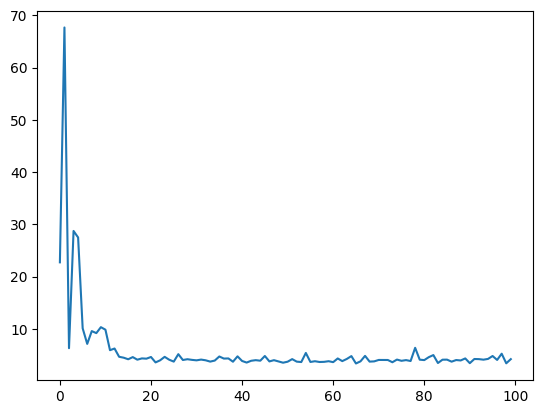

In [10]:
sns.lineplot(losses)

In [11]:
integration_steps = 64
times = torch.linspace(0, 1, integration_steps + 1).to(device)
x = torch.randn(20, 30, 4, device=device)
x_0 = x.detach().clone()
with torch.no_grad():
    model.eval()
    model.to(device)
    x = x.to(device)
    for i in range(integration_steps):
        print(f"Step {i+1}/{integration_steps}, x: mean={x.mean()}, std={x.std()}, t={times[i]}")
        x = model.step(x, times[i], times[i + 1])   

Step 1/64, x: mean=0.0027859187684953213, std=1.0072301626205444, t=0.0
Layer 0: vel shape=torch.Size([20, 30, 4]), mean=-3.1789145538141383e-08, std=14.53003978729248
Layer 1: vel shape=torch.Size([20, 30, 4]), mean=-3.1789145538141383e-08, std=43.676883697509766
Layer 2: vel shape=torch.Size([20, 30, 4]), mean=-6.695588439242783e-08, std=37.27865219116211
Layer 3: vel shape=torch.Size([20, 30, 4]), mean=-1.4781952017983713e-07, std=69.97355651855469
Layer 4: vel shape=torch.Size([20, 30, 4]), mean=2.531210441247822e-07, std=60.69487762451172
Layer 5: vel shape=torch.Size([20, 30, 4]), mean=1.1175871339474952e-09, std=0.6297538876533508
Step 2/64, x: mean=0.0027859245892614126, std=0.9998154044151306, t=0.015625
Layer 0: vel shape=torch.Size([20, 30, 4]), mean=-2.4636586104520575e-08, std=14.501163482666016
Layer 1: vel shape=torch.Size([20, 30, 4]), mean=1.5338261505348783e-07, std=43.6497917175293
Layer 2: vel shape=torch.Size([20, 30, 4]), mean=-4.212061455177718e-08, std=37.268749

In [12]:
# x = final_scale * x

In [13]:
x.shape

torch.Size([20, 30, 4])

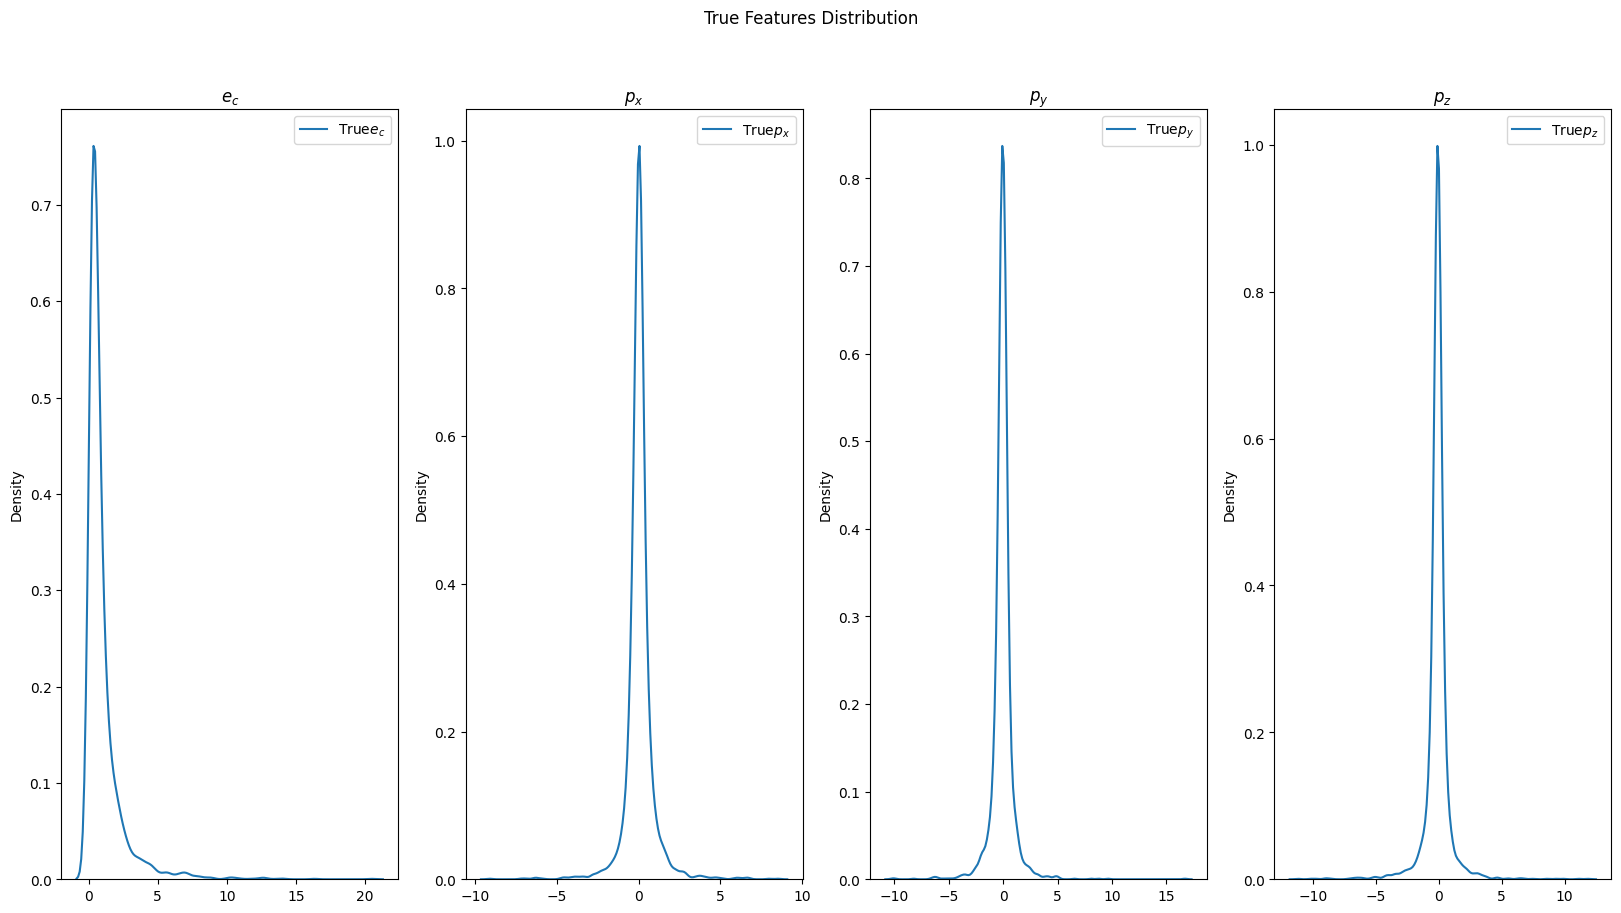

In [14]:
featuers = [r"$e_c$", r"$p_x$", r"$p_y$", r"$p_z$"]
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
plt.suptitle("True Features Distribution")
for i, feature in enumerate(featuers):
    sns.kdeplot(
        train_cloud_transformed[:, :, i].flatten().detach().cpu().numpy(),
        label="True" + feature,
        ax=axs[i]
    )
    axs[i].set_title(feature)
    axs[i].legend()

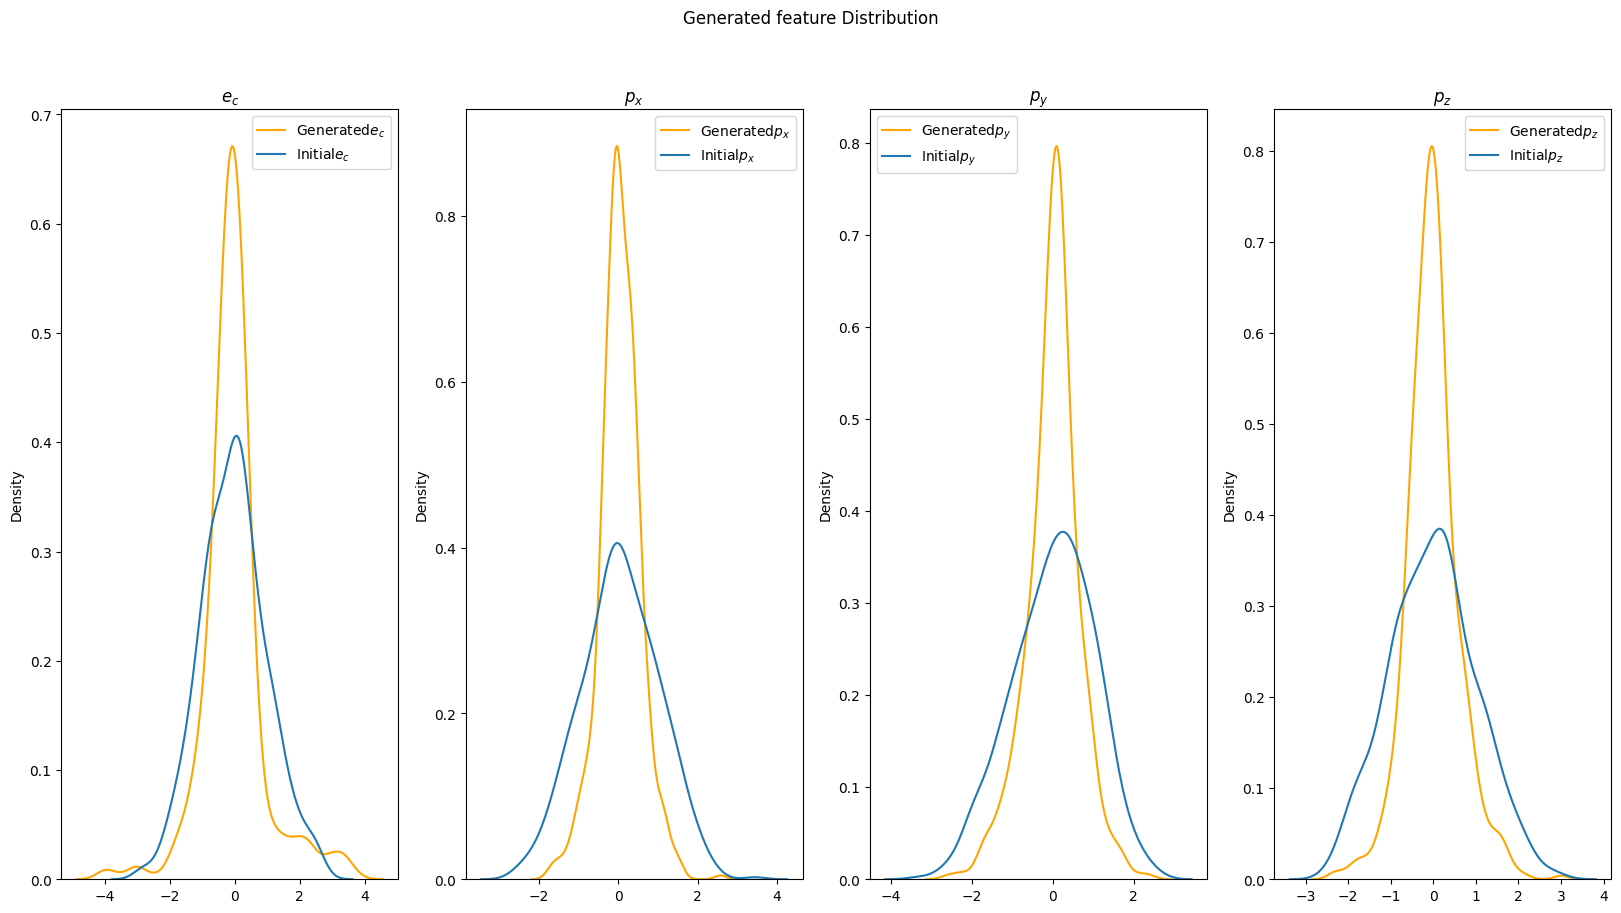

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
plt.suptitle("Generated feature Distribution")
for i, feature in enumerate(featuers):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(
        x[:, :, i].flatten().detach().cpu().numpy(),
        label="Generated" + feature,
        color='orange',
        ax=axs[i]
    )
    sns.kdeplot(
        x_0[:, :, i].flatten().detach().cpu().numpy(),
        label="Initial" + feature,
        ax=axs[i]
    )
    axs[i].set_title(feature)
    axs[i].legend()

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FlowMatchingMLP(nn.Module):
    def __init__(self, in_features, hidden_dim=128, time_embed_dim=32, num_layers=12):
        super().__init__()
        self.in_features = in_features

        # Embed time using simple MLP (you could also use Sinusoidal embeddings)
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.GELU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )

        # Input: particle features + time embedding
        input_dim = in_features + time_embed_dim
        layers = []
        for i in range(num_layers):
            d_in = input_dim if i == 0 else hidden_dim
            layers.append(nn.Linear(d_in, hidden_dim))
            layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dim, in_features))  # Output: velocity
        self.net = nn.Sequential(*layers)

        self.norm = nn.LayerNorm(in_features)

    def forward(self, x, t):
        """
        x: [batch_size, num_particles, in_features]
        t: [batch_size] or [batch_size, 1] or scalar
        Returns: velocity of shape [batch_size, num_particles, in_features]
        """
        B, N, F = x.shape
        x = self.norm(x)

        if isinstance(t, float) or len(t.shape) == 0:
            t = torch.tensor([t], device=x.device).repeat(B)
        t = t.view(B, 1, 1).expand(B, N, 1)  # shape: [B, N, 1]
        t_embed = self.time_embed(t)        # shape: [B, N, time_embed_dim]

        x_input = torch.cat([x, t_embed], dim=-1)  # shape: [B, N, F + time_embed_dim]
        x_flat = x_input.view(-1, x_input.shape[-1])
        v_flat = self.net(x_flat)
        v = v_flat.view(B, N, F)
        return v
    
    def step(self, x, t0, t1):
        """
        x: [batch_size, num_particles, in_features]
        t0: scalar or [batch_size] or [batch_size, 1]
        t1: scalar or [batch_size] or [batch_size, 1]
        Returns: updated x after one step of flow matching
        """
        v = self.forward(x, t0)
        dt = t1 - t0
        return x + v * dt

In [29]:
simple_model = FlowMatchingMLP(in_features=4)  # e.g. 4D: (E, px, py, pz)

In [30]:
train_cloud_transformed = train_cloud_transformed.to(device)

losses = []
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-3)


for epoch in range(100):
    epoch_loss = []
    # x_0 = torch.randn(n_samples, 30, 4, device=device)
    x_0 = sample_massless_4momentum_clouds(n_samples, NUM_PARTICLES, device=device)
    x_1 = train_cloud_transformed.to(device)

    t = torch.rand(x_0.shape[0], device=device).view(-1, 1, 1) 
    t = t.clone().detach().requires_grad_(True)  # Ensure t is a trainable parameter
    x_t = (1 - t) * x_0 + t * x_1  # Linear interpolation
    x_t = x_t.clone().detach().requires_grad_(True)  # Ensure x_t is a trainable parameter
    dx_t = x_1 - x_0
    # print(f"t={t}, dx_t: mean={dx_t.abs().mean()}, std={dx_t.abs().std()}")
    optimizer.zero_grad()

    loss = torch.nn.MSELoss()(simple_model.forward(x_t, t), dx_t)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item()}")
    losses.append(loss.item())

Epoch 0, Loss: 2988.602783203125
Epoch 1, Loss: 2988.89990234375
Epoch 2, Loss: 2988.564208984375
Epoch 3, Loss: 2988.31201171875
Epoch 4, Loss: 2987.360595703125
Epoch 5, Loss: 2986.129638671875
Epoch 6, Loss: 2987.24609375
Epoch 7, Loss: 2986.30029296875
Epoch 8, Loss: 2985.793701171875
Epoch 9, Loss: 2984.45458984375
Epoch 10, Loss: 2983.805908203125
Epoch 11, Loss: 2981.60791015625
Epoch 12, Loss: 2981.298583984375
Epoch 13, Loss: 2978.800048828125
Epoch 14, Loss: 2975.187744140625
Epoch 15, Loss: 2971.825927734375
Epoch 16, Loss: 2965.095703125
Epoch 17, Loss: 2955.279541015625
Epoch 18, Loss: 2940.310302734375
Epoch 19, Loss: 2913.927490234375
Epoch 20, Loss: 2877.35791015625
Epoch 21, Loss: 2825.792236328125
Epoch 22, Loss: 2753.2763671875
Epoch 23, Loss: 2666.370361328125
Epoch 24, Loss: 2607.662353515625
Epoch 25, Loss: 2720.369140625
Epoch 26, Loss: 2651.29541015625
Epoch 27, Loss: 2589.57763671875
Epoch 28, Loss: 2582.361083984375
Epoch 29, Loss: 2596.995361328125
Epoch 30, 

In [31]:
integration_steps = 64
times = torch.linspace(0, 1, integration_steps + 1).to(device)
x = torch.randn(20, 30, 4, device=device)
x_0 = x.detach().clone()
with torch.no_grad():
    model.eval()
    model.to(device)
    x = x.to(device)
    for i in range(integration_steps):
        print(f"Step {i+1}/{integration_steps}, x: mean={x.mean()}, std={x.std()}, t={times[i]}")
        x = simple_model.step(x, times[i], times[i + 1])

Step 1/64, x: mean=0.019329912960529327, std=0.9993583559989929, t=0.0
Step 2/64, x: mean=0.166891947388649, std=1.0484586954116821, t=0.015625
Step 3/64, x: mean=0.3162930905818939, std=1.1641000509262085, t=0.03125
Step 4/64, x: mean=0.4670743942260742, std=1.3304617404937744, t=0.046875
Step 5/64, x: mean=0.6187006235122681, std=1.5319111347198486, t=0.0625
Step 6/64, x: mean=0.7707992792129517, std=1.7567998170852661, t=0.078125
Step 7/64, x: mean=0.9231472611427307, std=1.9973766803741455, t=0.09375
Step 8/64, x: mean=1.0756430625915527, std=2.2486722469329834, t=0.109375
Step 9/64, x: mean=1.2282378673553467, std=2.507498025894165, t=0.125
Step 10/64, x: mean=1.3809062242507935, std=2.7717676162719727, t=0.140625
Step 11/64, x: mean=1.5336334705352783, std=3.040079116821289, t=0.15625
Step 12/64, x: mean=1.686410903930664, std=3.311465263366699, t=0.171875
Step 13/64, x: mean=1.8392330408096313, std=3.5852415561676025, t=0.1875
Step 14/64, x: mean=1.9920955896377563, std=3.860912

Text(0.5, 0.98, 'MLP generated features')

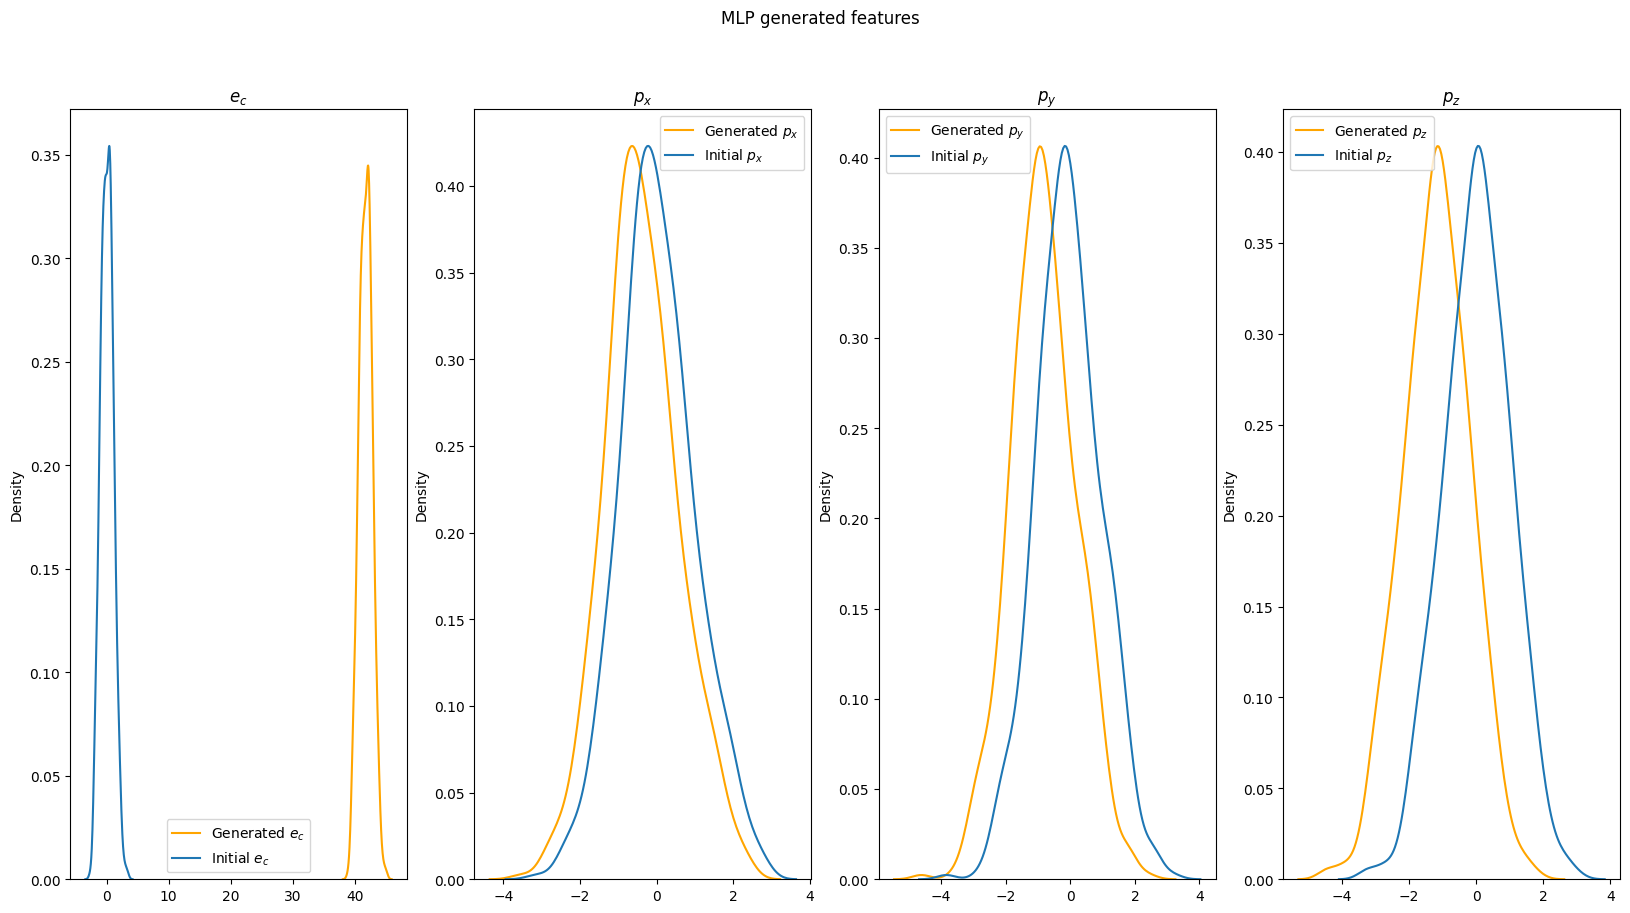

In [43]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))

plt.suptitle("Generated feature Distribution")
for i, feature in enumerate(featuers):
    sns.kdeplot(
        x[:, :, i].flatten().detach().cpu().numpy(),
        label="Generated " + feature,
        color='orange',
        ax=axs[i]
    )
    # sns.kdeplot(
    #     train_cloud_transformed[:, :, i].flatten().detach().cpu().numpy(),
    #     label="True " + feature,
    #     color='orange',
    #     ax=axs[i]
    # )
    sns.kdeplot(
        x_0[:, :, i].flatten().detach().cpu().numpy(),
        label="Initial " + feature,
        ax=axs[i]
    )
    axs[i].set_title(feature)
    axs[i].legend()
plt.suptitle("MLP generated features")

Text(0.5, 0.98, 'True feature Distribution')

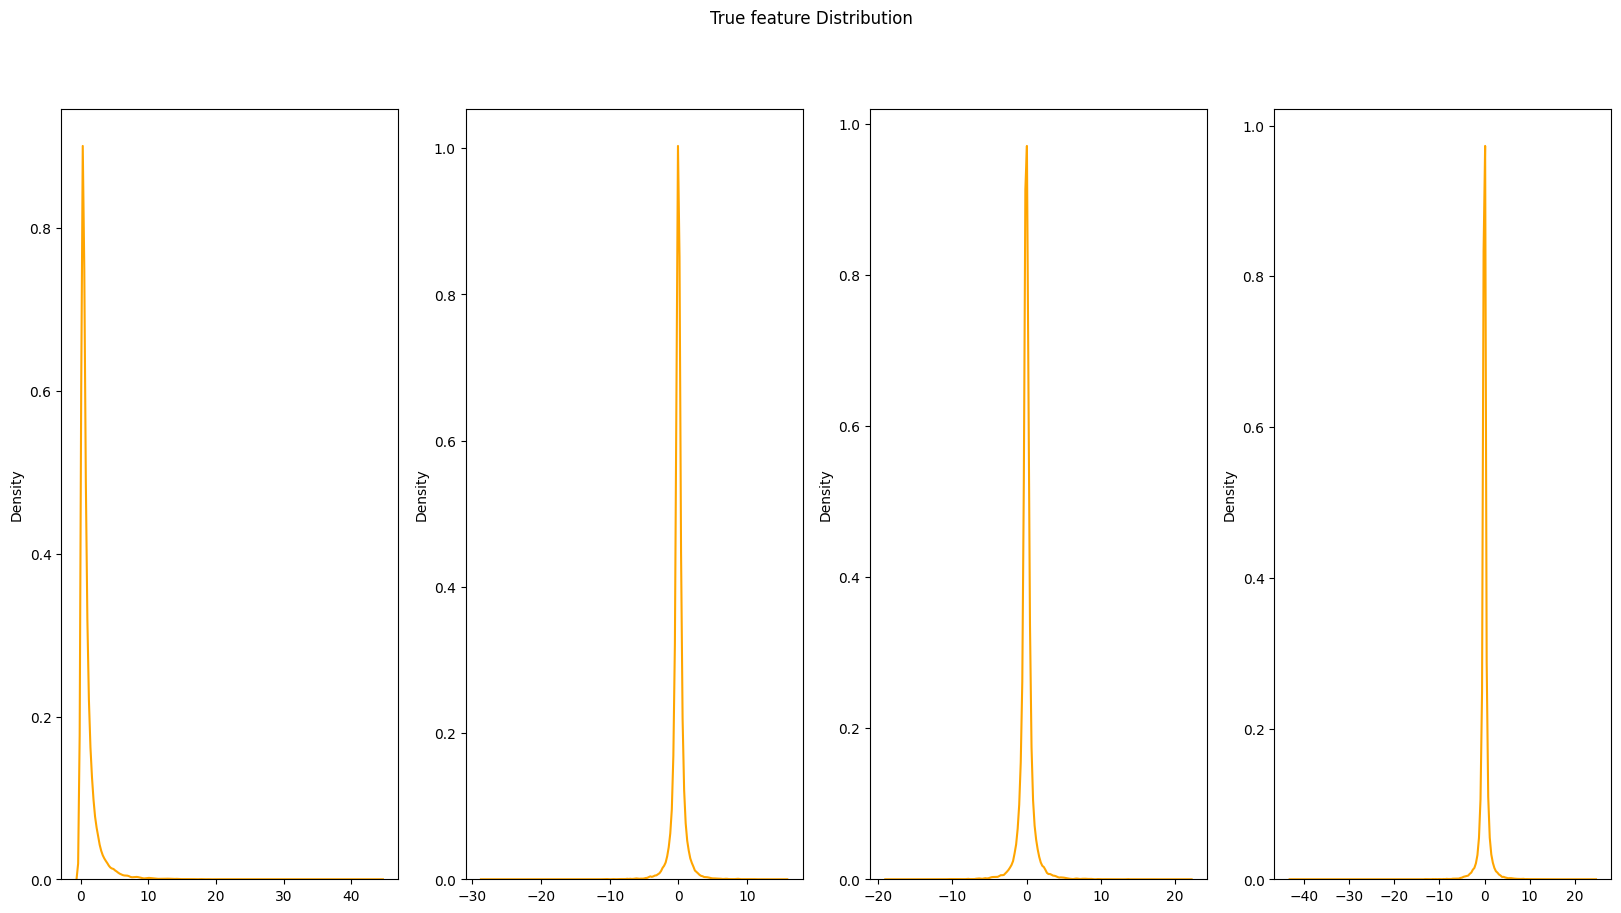

In [42]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
for i, feature in enumerate(featuers):
    sns.kdeplot(
        (1/final_scale) * train_cloud_transformed[:, :, i].flatten().detach().cpu().numpy(),
        label="True " + feature,
        color='orange',
        ax=axs[i]
    )
plt.suptitle("True feature Distribution")